# Revisão de código 

Olá! 

Meu nome é Suelen. Estou feliz em revisar seu projeto hoje!

Quando vejo um erro pela primeira vez, apenas aponto. Deixarei você encontrá-lo e corrigi-lo sozinho. Além disso, ao longo do texto, farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Mas se você ainda não consegue lidar com essa tarefa, darei uma dica mais precisa na próxima iteração e também alguns exemplos práticos. Estarei aberto a feedbacks e discussões sobre o tema.

Você pode encontrar meus comentários em caixas verdes, amarelas ou vermelhas como estas:


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Sucesso. Tudo está correto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

Observações. Algumas recomendações.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário: </b> <a class="tocSkip"></a>

O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.
</div>

Você pode me responder usando isto:

<div class="alert alert-block alert-info">
<b>Resposta do aluno
    </b> 
<a class="tocSkip"></a>
</div>



<div class="alert alert-block alert-danger">

<b>Comentário geral V1: </b> <a class="tocSkip"></a>


Parabéns pela conclusão do projeto, Ricardo! 🎉

O seu trabalho já demonstra excelente qualidade! Como comentários positivos, destaco: 
    
    
- Código organizado e com comentários em cada etapa
- Boa análise crítica dos dados 
- Visualizações com boa legibilidade
    
    
Para concluirmos a aprovação, precisamos fazer alguns ajustes:

    - Análise de taxa de retenção
    - LTV por coortes
    - Taxa de ROI por coortes
    
    
    
    
Incluí comentários ao longo do código para te auxiliar nessa tarefa.
    
    
    

Fico à disposição para eventuais dúvidas. 

Boa sorte! 🍀
</div>

<div class="alert alert-block alert-danger">
<b> Comentário geral: </b> <a class="tocSkip"></a>

Oi, Ricardo! Obrigada pelos ajustes. Vi seu comentário relatando as dificuldades enfrentadas. 
    


Deixo abaixo as etapas mais detalhadas que você precisa executar para calcular essas métricas. O dataframe gerado ao final pode ser usado para os cálculos de LTV e ROI.

<br> 
   
    
**1. Calcule o primeiro pedido de cada usuário e extraia o mês.** - 
```python
first_orders_df = orders_df.groupby("..").agg({"Buy Ts": "min"}).reset_index().rename(columns={"Buy Ts": "first_purchase"})
first_orders_df['first_purchase_month'] = first_orders_df['first_purchase'].dt.to_period("M")
```

**2. Faça o merge entre o primeiro pedido e os dados de source pelo `ID`.**
```pyhton
user_source = visits_df[['..', 'Source Id']].drop_duplicates()
first_orders_df = pd.merge(first_orders_df, user_source, on= '..')
```

**3. Calcule a receita mensal e faça o merge com a tabela criada anteriormente.**
```python
revenue_df = orders_df.groupby(['Uid', 'month']).agg({'Revenue': 'sum'}).reset_index()
buyers = first_orders_df.merge(revenue_df, on='Uid')
```

**4. Calcule a receita e os custos.**
```python
revenue_grouped_df = buyers.groupby(['..', 'month']).agg({'Revenue': 'sum'}).reset_index()
costs_grouped_df = costs_df.groupby(['..','month']).agg({'costs': 'sum'})
```
    
**5. Por fim, gere um dataframe por `source` e `month` com os dados de receita e custo.**
    
    
```python
report = pd.merge(
    costs_grouped_df, 
    revenue_grouped_df, 
    left_on=['...','month'], 
    right_on=['...', 'month']
)
```

O dataframe resultante dessas etapas é mostrado abaixo. Com esses dados, você consegue criar as métricas e executar as etapas restantes do seu projeto.
```
      costs	month	Source Id	Revenue
0	1125.61	2017-06	  1	     2563.84
1	1072.88	2017-07	  1	     3947.25
2	951.81	2017-08	   1	     3325.64
3	1502.01	2017-09	  1	     8193.42
4	2315.75	2017-10	  1	     11466.14
```


Caso apresente dúvidas, por favor fique a vontade para me sinalizar
    
Boa sorte!😊
</div>

In [1]:
import sys
print(sys.executable)
import pandas as pd
print(pd.__file__)

d:\Users\madki\miniconda3\envs\TripleTen\python.exe
d:\Users\madki\miniconda3\envs\TripleTen\Lib\site-packages\pandas\__init__.py


<div class="alert alert-block alert-success">
<b> Comentário geral v3: </b> <a class="tocSkip"></a>

Obrigadaaa pelos ajustes! Projeto aprovadíssimo :) 

In [1]:
#Importando bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Carregando os dados de visitas, pedidos e de custos.

In [2]:
visits_logs = pd.read_csv('../data/visits_log_us.csv', parse_dates=['Start Ts', 'End Ts'])

In [3]:
orders_logs = pd.read_csv('../data/orders_log_us.csv', parse_dates=['Buy Ts'])

In [4]:
costs_logs = pd.read_csv('../data/costs_us.csv', parse_dates=['dt'])

<div class="alert alert-block alert-success">
<b> Comentário: </b> <a class="tocSkip"></a>
    
- O import das bibliotecas foi feito de forma correta
- Os dados foram carregados corretamente.


</div>

Verificando os DataFrames

In [5]:
visits_logs.info()

<class 'pandas.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  str           
 1   End Ts     359400 non-null  datetime64[us]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[us]
 4   Uid        359400 non-null  uint64        
dtypes: datetime64[us](2), int64(1), str(1), uint64(1)
memory usage: 13.7 MB


In [6]:
orders_logs.info()

<class 'pandas.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[us]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[us](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [7]:
costs_logs.info()

<class 'pandas.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[us]
 2   costs      2542 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 59.7 KB


Tratando os DataFrames

In [8]:
visits_logs['Device'] = visits_logs['Device'].astype('category')
visits_logs.info()

<class 'pandas.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  category      
 1   End Ts     359400 non-null  datetime64[us]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[us]
 4   Uid        359400 non-null  uint64        
dtypes: category(1), datetime64[us](2), int64(1), uint64(1)
memory usage: 11.3 MB


In [9]:
visits_logs.duplicated().sum()

np.int64(0)

In [10]:
orders_logs.duplicated().sum()

np.int64(0)

In [11]:
costs_logs.duplicated().sum()

np.int64(0)

Calculando métricas das visitas

In [12]:
#Criando colunas das sessões de diferentes expressões de tempo.

visits_logs['session_day'] = visits_logs['Start Ts'].dt.date
visits_logs['session_week'] = visits_logs['Start Ts'].dt.isocalendar().week 
visits_logs['session_month'] = visits_logs['Start Ts'].dt.month
visits_logs['session_year'] = visits_logs['Start Ts'].dt.year

In [13]:
#Calculando a média de usuários ativos em diferentes expressões de tempo.

dau_total = visits_logs.groupby('session_day').agg({'Uid': 'nunique'}).mean()
wau_total = visits_logs.groupby(['session_year','session_week']).agg({'Uid': 'nunique'}).mean()
mau_total = visits_logs.groupby(['session_year','session_month']).agg({'Uid': 'nunique'}).mean()


In [14]:
#Imprimindo o resultado.

print(dau_total, wau_total, mau_total)

Uid    907.991758
dtype: float64 Uid    5716.245283
dtype: float64 Uid    23228.416667
dtype: float64


In [ ]:
#Número de visitas diárias

sessions_users_day = visits_logs.groupby('session_day').agg({'Uid': ['count', 'nunique']})
sessions_users_day.columns = ['n_sessions', 'n_users']
sessions_users_day['sess_per_user'] = sessions_users_day['n_sessions'] / sessions_users_day['n_users']
print(sessions_users_day)

             n_sessions  n_users  sess_per_user
session_day                                    
2017-06-01          664      605       1.097521
2017-06-02          658      608       1.082237
2017-06-03          477      445       1.071910
2017-06-04          510      476       1.071429
2017-06-05          893      820       1.089024
...                 ...      ...            ...
2018-05-27          672      620       1.083871
2018-05-28         1156     1039       1.112608
2018-05-29         1035      948       1.091772
2018-05-30         1410     1289       1.093871
2018-05-31         2256     1997       1.129695

[364 rows x 3 columns]


In [ ]:
#Calculando o tempo médio das sessões diárias

visits_logs['session_duration_min'] = (visits_logs['End Ts'] - visits_logs['Start Ts']).dt.total_seconds() / 60
asl_daily = visits_logs.groupby('session_day')['session_duration_min'].mean()
print(asl_daily.head())

session_day
2017-06-01    11.105346
2017-06-02    10.330674
2017-06-03    10.115968
2017-06-04     9.238497
2017-06-05    10.407503
Name: session_duration_min, dtype: float64


In [17]:
#Calculando as frequência que os usuários voltam
#Não consegui pensar em como poderia calcular isso,
#fiz a média total das sessões dos usuários.

print('Os usuários entram em média: ', sessions_users_day['sess_per_user'].mean().round(2), ' vezes por dia.')

Os usuários entram em média:  1.08  vezes por dia.


In [18]:
first_visit = visits_logs.groupby('Uid')['Start Ts'].min()
first_visit.head()

Uid
11863502262781    2018-03-01 17:27:00
49537067089222    2018-02-06 15:55:00
297729379853735   2017-06-07 18:47:00
313578113262317   2017-09-18 22:49:00
325320750514679   2017-09-30 14:29:00
Name: Start Ts, dtype: datetime64[us]

In [19]:
first_visit.name = 'first_visit'

In [20]:
visits_logs = visits_logs.join(first_visit, on='Uid')

In [21]:
visits_logs.loc[visits_logs['Uid'] == 18370831553019119586]

,Device,End Ts,Source Id,Start Ts,Uid,session_day,session_week,session_month,session_year,session_duration_min,first_visit
129714,touch,2018-01-25 22:30:00,1,2018-01-25 22:28:00,18370831553019119586,2018-01-25,4,1,2018,2.000000,2018-01-25 17:38:00
228297,touch,2018-01-30 21:00:00,4,2018-01-30 20:54:00,18370831553019119586,2018-01-30,5,1,2018,6.000000,2018-01-25 17:38:00
359396,touch,2018-01-25 17:38:19,1,2018-01-25 17:38:00,18370831553019119586,2018-01-25,4,1,2018,0.316667,2018-01-25 17:38:00


In [22]:
visits_logs['lifetime'] = visits_logs['Start Ts'] - visits_logs['first_visit']
visits_logs.tail()

,Device,End Ts,Source Id,Start Ts,Uid,session_day,session_week,session_month,session_year,session_duration_min,first_visit,lifetime
359395,desktop,2017-07-29 19:07:19,2,2017-07-29 19:07:00,18363291481961487539,2017-07-29,30,7,2017,0.316667,2017-07-29 19:07:00,0 days
359396,touch,2018-01-25 17:38:19,1,2018-01-25 17:38:00,18370831553019119586,2018-01-25,4,1,2018,0.316667,2018-01-25 17:38:00,0 days
359397,desktop,2018-03-03 10:12:19,4,2018-03-03 10:12:00,18387297585500748294,2018-03-03,9,3,2018,0.316667,2018-03-03 10:12:00,0 days
359398,desktop,2017-11-02 10:12:19,5,2017-11-02 10:12:00,18388616944624776485,2017-11-02,44,11,2017,0.316667,2017-11-02 10:12:00,0 days
359399,touch,2017-09-10 13:13:19,2,2017-09-10 13:13:00,18396128934054549559,2017-09-10,36,9,2017,0.316667,2017-09-10 13:13:00,0 days


In [23]:
visits_logs['first_month'] = visits_logs['first_visit'].dt.to_period('M')
visits_logs['session_month_period'] = visits_logs['Start Ts'].dt.to_period('M')

# Calcule o lifetime em meses, não em dias/segundos
visits_logs['lifetime_months'] = (visits_logs['session_month_period'] - visits_logs['first_month']).apply(lambda x: x.n)

# Agora crie a análise de coorte com dados agregados
cohort = visits_logs.groupby(['first_month', 'lifetime_months']).agg({'Uid': 'nunique'}).reset_index()

In [24]:
visits_logs.head()

,Device,End Ts,Source Id,Start Ts,Uid,session_day,session_week,session_month,session_year,session_duration_min,first_visit,lifetime,first_month,session_month_period,lifetime_months
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-20,51,12,2017,18.0,2017-12-20 17:20:00,0 days 00:00:00,2017-12,2017-12,0
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-19,8,2,2018,28.0,2018-02-19 16:53:00,0 days 00:00:00,2018-02,2018-02,0
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,26,7,2017,0.0,2017-07-01 01:54:00,0 days 00:00:00,2017-07,2017-07,0
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-20,20,5,2018,24.0,2018-03-09 20:05:00,71 days 14:54:00,2018-03,2018-05,2
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-27,52,12,2017,0.0,2017-12-27 14:06:00,0 days 00:00:00,2017-12,2017-12,0


In [25]:
cohort.head()

,first_month,lifetime_months,Uid
0,2017-06,0,13259
1,2017-06,1,1043
2,2017-06,2,713
3,2017-06,3,814
4,2017-06,4,909


In [26]:
inicial = cohort[cohort['lifetime_months'] == 0][['first_month', 'Uid']]
inicial = inicial.rename(columns={'Uid': 'users'})
inicial.info()

<class 'pandas.DataFrame'>
Index: 12 entries, 0 to 77
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype    
---  ------       --------------  -----    
 0   first_month  12 non-null     period[M]
 1   users        12 non-null     int64    
dtypes: int64(1), period[M](1)
memory usage: 288.0 bytes


In [27]:
cohort.head()

,first_month,lifetime_months,Uid
0,2017-06,0,13259
1,2017-06,1,1043
2,2017-06,2,713
3,2017-06,3,814
4,2017-06,4,909


In [28]:
cohort = cohort.merge(inicial, on='first_month')
cohort['retention'] = ((cohort['Uid'] / cohort['users']) * 100).round(2)
print(cohort.head(10))

  first_month  lifetime_months    Uid  users  retention
0     2017-06                0  13259  13259     100.00
1     2017-06                1   1043  13259       7.87
2     2017-06                2    713  13259       5.38
3     2017-06                3    814  13259       6.14
4     2017-06                4    909  13259       6.86
5     2017-06                5    947  13259       7.14
6     2017-06                6    809  13259       6.10
7     2017-06                7    766  13259       5.78
8     2017-06                8    694  13259       5.23
9     2017-06                9    674  13259       5.08


In [29]:
retention_pivot = cohort.pivot_table(
    index='first_month',
    columns='lifetime_months',
    values='retention',
    aggfunc='sum'
)
print(retention_pivot)

lifetime_months     0     1     2     3     4     5     6     7     8     9   \
first_month                                                                    
2017-06          100.0  7.87  5.38  6.14  6.86  7.14  6.10  5.78  5.23  5.08   
2017-07          100.0  5.61  5.13  5.62  5.82  4.82  4.54  4.57  3.88  2.86   
2017-08          100.0  7.69  6.29  6.28  5.01  4.40  3.63  3.95  2.79  2.60   
2017-09          100.0  8.55  6.92  5.07  3.94  3.78  3.59  2.42  2.28   NaN   
2017-10          100.0  7.86  5.22  3.90  3.43  3.22  2.14  2.04   NaN   NaN   
2017-11          100.0  7.83  4.41  3.87  3.37  2.34  2.18   NaN   NaN   NaN   
2017-12          100.0  5.58  3.80  3.11  2.03  1.90   NaN   NaN   NaN   NaN   
2018-01          100.0  5.97  3.93  2.50  2.02   NaN   NaN   NaN   NaN   NaN   
2018-02          100.0  5.71  2.55  2.01   NaN   NaN   NaN   NaN   NaN   NaN   
2018-03          100.0  4.18  2.71   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2018-04          100.0  4.84   NaN   NaN

In [30]:
mean_retention = retention_pivot.mean().round(2)
print(mean_retention)

lifetime_months
0     100.00
1       6.52
2       4.63
3       4.28
4       4.06
5       3.94
6       3.70
7       3.75
8       3.54
9       3.51
10      3.41
11      4.50
dtype: float64


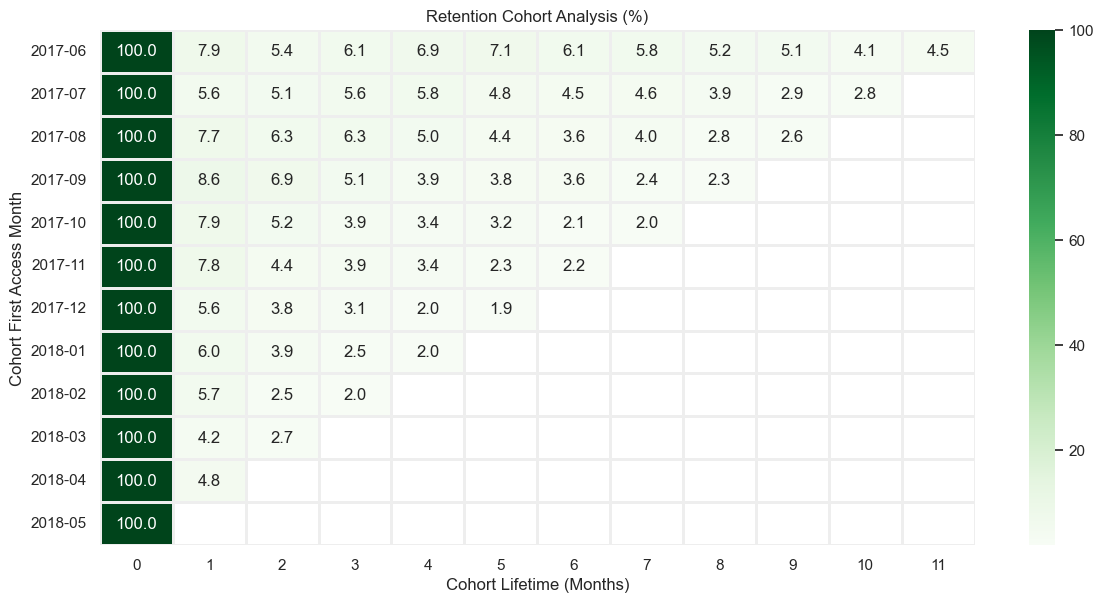

In [31]:
sns.set_theme(style='white')
plt.figure(figsize=(12,6))
plt.title('Retention Cohort Analysis (%)')
sns.heatmap(retention_pivot, annot=True, linewidths=1, linecolor='#EEEEEE', cmap='Greens', fmt='.1f')
plt.xlabel('Cohort Lifetime (Months)')
plt.ylabel('Cohort First Access Month')
plt.tight_layout(pad=0.5)

plt.show()

<div class="alert alert-block alert-danger">

<b>Comentário: </b> <a class="tocSkip"></a>
    

    

A taxa de retenção deve ser realizada por coorte.

O passo a passo é o seguinte:
    
1. Você precisa pegar a data do primeiro acesso de cada usuário
2. Para calcular o intervalo ou cohort de acesso para cada usuário, você precisa calcular o intervalo entre o acesso atual e o primeiro acesso:</s>
3. A partir desses dados, você pode criar uma tabela dinâmica (`pivot_table`) que indexa por cada mês do conjunto de dados e calcula a quantidade de usuários que teve o primeiro acesso naquele mês e voltou a acessar no futuro (`cohort`): 1 mês depois, 2 meses depois, etc. 


Exemplo: 

```python

# Calcula a vida útil de cada visita em meses
df_visits['lifetime'] = (df_visits['month'] - df_visits['first_month']).apply(lambda x: x.n)

# Calcula a coorte de usuários por mês de primeira visita e tempo de vida
cohort = df_visits.groupby(['first_month', 'lifetime']).agg({'uid': 'nunique'}).reset_index()

# Seleciona a coorte inicial (lifetime == 0) e renomeia a coluna de contagem de usuários
inicial = cohort[cohort['lifetime'] == 0][['first_month', 'uid']]
inicial = inicial.rename(columns={'uid': 'users'})

# Junta a coorte inicial com a coorte completa e calcula a taxa de retenção
cohort = cohort.merge(inicial, on='first_month')
cohort['retention'] = cohort['uid'] / cohort['users']

# Cria uma tabela dinâmica de retenção por mês de primeira visita e tempo de vida
retention_pivot = cohort.pivot_table(index='first_month', columns='lifetime', values='retention', aggfunc='sum')

# Imprime a tabela de retenção
print(retention_pivot)
```

O output esperado deve ser semelhante a esse: 

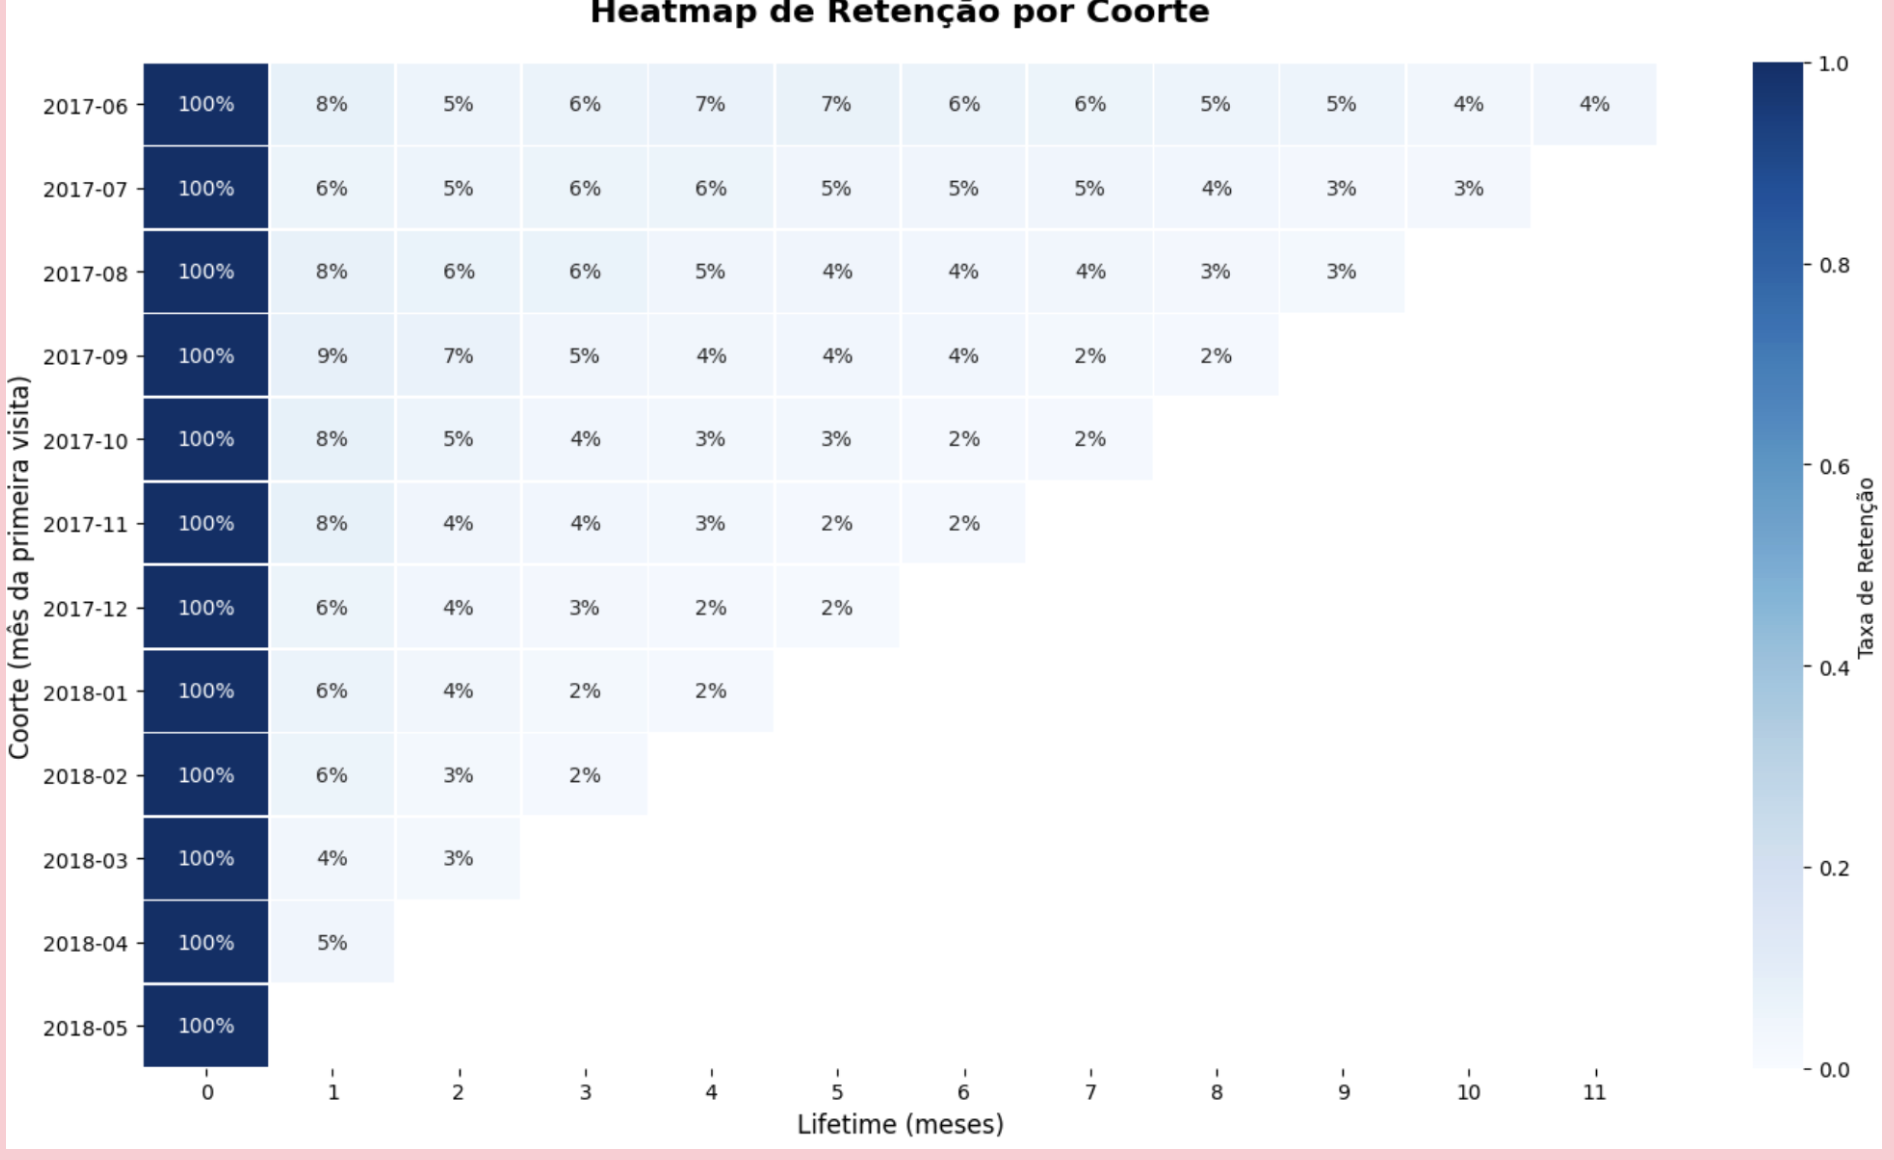

<div class="alert alert-block alert-success">
<b> Comentário v2: </b> <a class="tocSkip"></a>
<s>  
Ótimo trabalho no cálculo de LTV!
</div>

Calculando métricas das vendas

In [32]:
orders_logs.head()

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [33]:
#Mesclando os DataFrames

ord_vis_logs = visits_logs.merge(orders_logs, left_on='Uid', right_on='Uid')
ord_vis_logs.head()

,Device,End Ts,Source Id,Start Ts,Uid,session_day,session_week,session_month,session_year,session_duration_min,first_visit,lifetime,first_month,session_month_period,lifetime_months,Buy Ts,Revenue
0,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-20,20,5,2018,24.0,2018-03-09 20:05:00,71 days 14:54:00,2018-03,2018-05,2,2018-03-09 20:25:00,2.33
1,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387,2017-09-03,35,9,2017,1.0,2017-09-03 21:35:00,0 days 00:00:00,2017-09,2017-09,0,2017-09-04 12:46:00,2.44
2,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387,2017-09-03,35,9,2017,1.0,2017-09-03 21:35:00,0 days 00:00:00,2017-09,2017-09,0,2017-10-28 00:01:00,1.53
3,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387,2017-09-03,35,9,2017,1.0,2017-09-03 21:35:00,0 days 00:00:00,2017-09,2017-09,0,2017-10-28 19:16:00,1.53
4,desktop,2018-02-06 15:50:00,4,2018-02-06 15:45:00,8056418121947262981,2018-02-06,6,2,2018,5.0,2017-06-04 14:17:00,247 days 01:28:00,2017-06,2018-02,8,2017-06-25 08:54:00,3.67


In [34]:
#Agrupando o DataFrame pelo id dos usuários e capturando os horários mínimos

time_till_order = ord_vis_logs.groupby('Uid').agg({'Start Ts': 'min', 'Buy Ts': 'min'})
time_till_order

,Start Ts,Buy Ts
Uid,,
313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00
1575281904278712,2017-06-03 10:13:00,2017-06-03 10:13:00
2429014661409475,2017-10-11 17:14:00,2017-10-11 18:33:00
2464366381792757,2018-01-27 20:10:00,2018-01-28 15:54:00
2551852515556206,2017-11-24 10:14:00,2017-11-24 10:14:00
...,...,...
18445147675727495770,2017-08-20 13:30:00,2017-11-24 09:03:00
18445407535914413204,2017-09-22 23:48:00,2017-09-22 23:55:00
18445601152732270159,2017-08-07 11:51:00,2018-03-26 22:54:00


In [ ]:
#Criando uma coluna com a diferença da 1a compra com a 1a sessão

time_till_order['how_long_to_order'] = (time_till_order['Buy Ts'] - time_till_order['Start Ts']).reset_index()
time_till_order.head()

,Start Ts,Buy Ts,how_long_to_order
Uid,,,
313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00,106 days 23:02:00
1575281904278712,2017-06-03 10:13:00,2017-06-03 10:13:00,0 days 00:00:00
2429014661409475,2017-10-11 17:14:00,2017-10-11 18:33:00,0 days 01:19:00
2464366381792757,2018-01-27 20:10:00,2018-01-28 15:54:00,0 days 19:44:00
2551852515556206,2017-11-24 10:14:00,2017-11-24 10:14:00,0 days 00:00:00


In [36]:
#Mediana da duração até o usuário fazer a primeira compra

time_till_order['how_long_to_order'].median()

Timedelta('0 days 00:16:00')

In [37]:
#Agrupando a contagem de compras por mês

orders_months = ord_vis_logs.groupby('session_month').agg({'Buy Ts': 'count'})
mean_orders = orders_months['Buy Ts'].mean().round(0)
print(orders_months.head())
print(f'Os usuários fazem em média {mean_orders} de compras por mês.' )

               Buy Ts
session_month        
1               77651
2               82787
3               75988
4               60157
5               70114
Os usuários fazem em média 63484.0 de compras por mês.


In [38]:
#Agrupando a receita pelo registro da compra

order_vol = ord_vis_logs.groupby('Buy Ts').agg({'Revenue': 'mean'}).reset_index().round(3)
order_vol.head()

C:\Users\madki\AppData\Local\Temp\ipykernel_25420\2788237157.py:3: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  order_vol = ord_vis_logs.groupby('Buy Ts').agg({'Revenue': 'mean'}).reset_index().round(3)


,Buy Ts,Revenue
0,2017-06-01 00:10:00,17.00
1,2017-06-01 00:25:00,0.55
2,2017-06-01 00:27:00,0.37
3,2017-06-01 00:29:00,0.55
4,2017-06-01 07:58:00,0.37


In [39]:
#Calculando a média e a mediana da coluna de receita

mean_ov = order_vol['Revenue'].mean().round(2)
median_ov = order_vol['Revenue'].median()
print(mean_ov, median_ov)

5.05 2.67


In [40]:
#Agrupando a soma da receita para cada usuário

ltv = ord_vis_logs.groupby('Uid').agg({'Revenue': 'sum'}).reset_index()
ltv.head()

,Uid,Revenue
0,313578113262317,1.65
1,1575281904278712,6.10
2,2429014661409475,73.33
3,2464366381792757,4.88
4,2551852515556206,21.98


In [41]:
#Calculando e imprimindo a média e a mediana da receita total de cada usuário

mean_ltv = ltv['Revenue'].mean().round(2)
median_ltv = ltv['Revenue'].median().round(2)
print(mean_ltv, median_ltv)

190.63 4.64


<div class="alert alert-block alert-danger">
<b> Comentário: </b> <a class="tocSkip"></a>

A análise LTV tambem precisa ser feita por coortes

Adiciono abaixo um passo a passo para a resolução do problema:
    
Passo 1: Criar Coluna de Mês do Pedido
Primeiro, criamos uma nova coluna em nosso DataFrame que representa o mês de cada compra.

```python

# Criando a coluna 'order_month' a partir da coluna 'buy_ts' que contém a data de compra
df_logs['order_month'] = df_logs['buy_ts'].dt.to_period('M')
```
Passo 2: Identificar o Mês da Primeira Compra
Em seguida, encontramos o mês da primeira compra para cada usuário.

```python
# Primeira Compra
first_order_month = df_logs.groupby("uid")['order_month'].min().reset_index().rename(columns={'order_month': 'first_order_month'})
```
Passo 3: Mesclar Dados de Primeira Compra com o DataFrame Original
Agora, mesclamos o DataFrame original com o DataFrame que contém a data da primeira compra de cada usuário.

```python
# Mesclando o DataFrame original com o DataFrame que contém a data da primeira compra de cada usuário
cohort = pd.merge(df_logs, first_order_month, on='uid')
```
Passo 4: Calcular Diferença em Meses
Calculamos a diferença em meses entre o mês da compra atual e o mês da primeira compra.

```python
# Calculando a diferença em meses entre a compra atual e a primeira compra
cohort['month_diff'] = (cohort['order_month'].astype('int64') - cohort['first_order_month'].astype('int64'))
```
Passo 5: Calcular o Número de Compradores por Coorte
Agora, calculamos quantos compradores existem em cada coorte.

```python
# Calculando o número de compradores por coorte
cohort_sizes = cohort.groupby('first_order_month')['uid'].nunique().reset_index()
cohort_sizes.rename(columns={'uid': 'n_buyers'}, inplace=True)
```
Passo 6: Mesclar Tamanhos de Coorte com o DataFrame

Mesclamos o DataFrame de tamanhos de coorte com o DataFrame principal para obter as informações de compradores.

```python
# Mesclando o DataFrame de cohort sizes com o DataFrame original
cohort = pd.merge(cohort, cohort_sizes, left_on='first_order_month', right_on='first_order_month')
```
Passo 7: Calcular LTV
Agora podemos calcular o LTV dividindo a receita pela quantidade de compradores para cada coorte.

```python
# Calculando o LTV para cada coorte e período de tempo (em meses) após a primeira compra
cohort['ltv'] = cohort['revenue'] / cohort['n_buyers']
```
Passo 8: Criar uma Tabela Dinâmica
Criamos uma tabela dinâmica para organizar os dados de LTV.

```python
# Criando a Tabela Dinâmica
output = cohort.pivot_table(
    index='first_order_month',
    columns='month_diff',
    values='ltv',
    aggfunc='sum'
)
```
Passo 9: Calcular LTV Acumulado
Calculamos o LTV acumulado ao longo do tempo para cada coorte.

```python
# Calculando o LTV acumulado ao longo do tempo para cada coorte
ltv_cumsum = output.cumsum(axis=1).round(2)
```
Passo 10: Substituir Strings Vazias por NaN
Substituímos as strings vazias por NaN para evitar problemas na visualização.

```python

# Substituindo strings vazias por NaN
ltv_cumsum.replace('', np.nan, inplace=True)
```
Passo 11: Gerar o Heatmap

 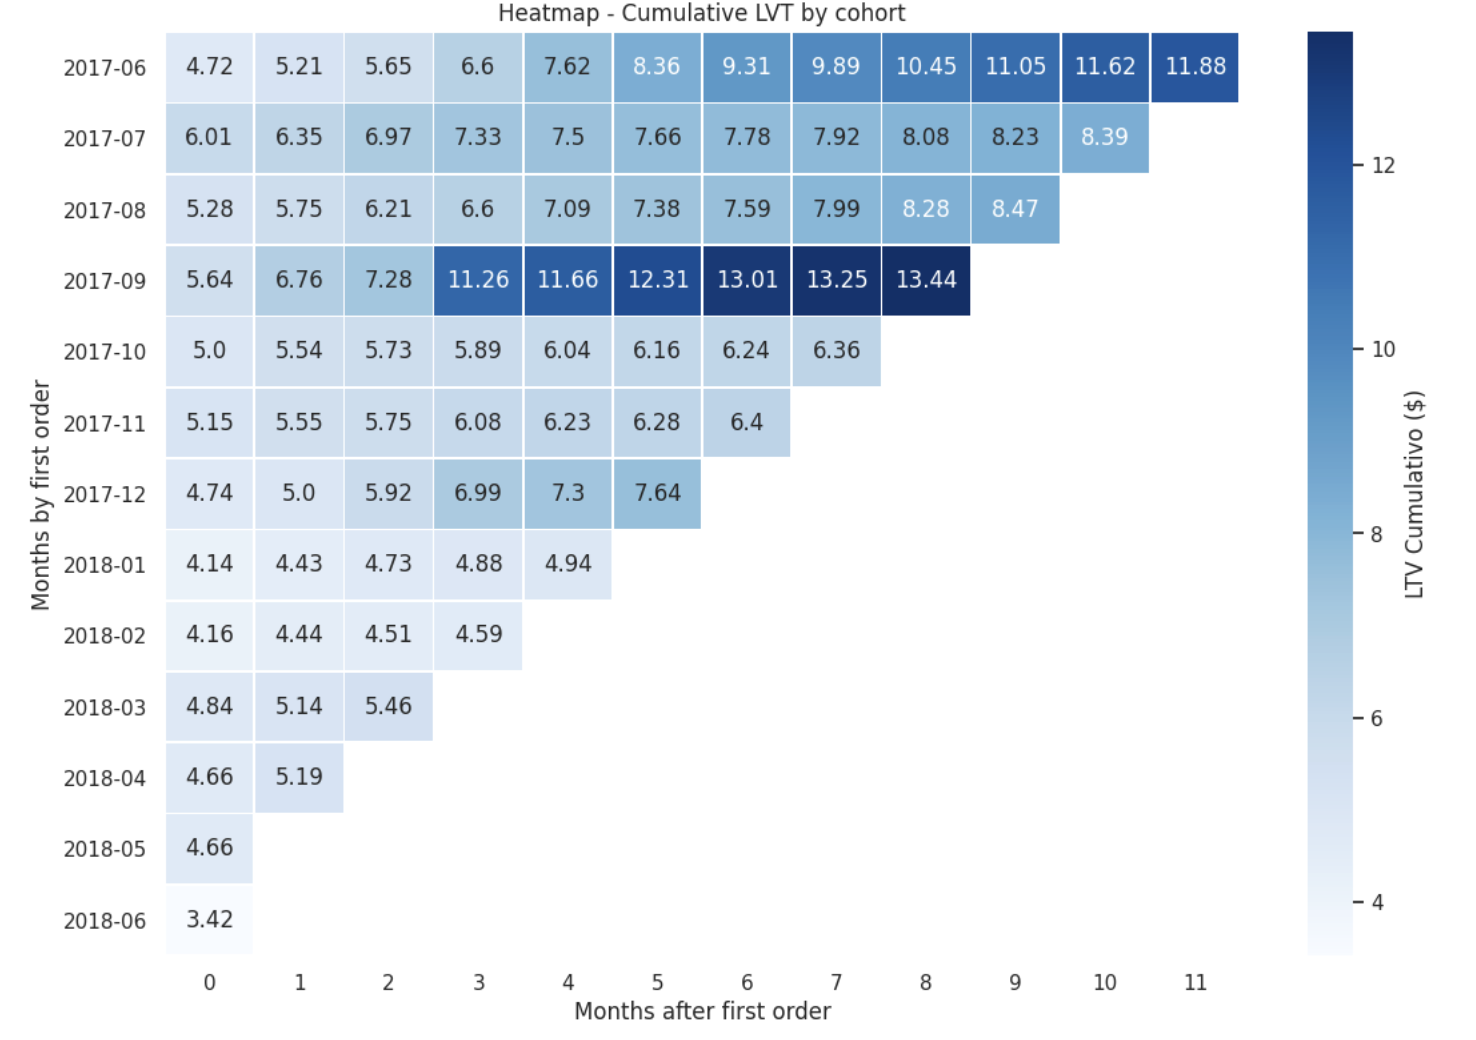

Calculando métricas dos custos

In [42]:
costs_logs

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08
...,...,...,...
2537,10,2018-05-27,9.92
2538,10,2018-05-28,21.26
2539,10,2018-05-29,11.32
2540,10,2018-05-30,33.15


In [43]:
#Criando a coluna de mês para poder agrupar posteriormente

costs_logs['month'] = costs_logs['dt'].dt.month
costs_logs.head()

,source_id,dt,costs,month
0,1,2017-06-01,75.20,6
1,1,2017-06-02,62.25,6
2,1,2017-06-03,36.53,6
3,1,2017-06-04,55.00,6
4,1,2017-06-05,57.08,6


In [44]:
#Agrupando a soma dos custos por tipo e mês

costs = costs_logs.groupby(['source_id', 'month']).agg({'costs': 'sum'}).reset_index()
costs.head()

,source_id,month,costs
0,1,1,2186.18
1,1,2,2204.48
2,1,3,1893.09
3,1,4,1327.49
4,1,5,1467.61


In [45]:
#Calculando o ROI usando os custos como investimento

total_costs = costs['costs'].sum()
total_revenue = ltv['Revenue'].sum()
roi = abs(((total_costs - total_revenue.round(2)) / total_costs).round(2))
print(f'Ainda falta {roi}% para recuperar o dinheiro do investimento')

Ainda falta 20.15% para recuperar o dinheiro do investimento


Projetando gráficos

In [46]:
ord_vis_logs.head()

,Device,End Ts,Source Id,Start Ts,Uid,session_day,session_week,session_month,session_year,session_duration_min,first_visit,lifetime,first_month,session_month_period,lifetime_months,Buy Ts,Revenue
0,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-20,20,5,2018,24.0,2018-03-09 20:05:00,71 days 14:54:00,2018-03,2018-05,2,2018-03-09 20:25:00,2.33
1,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387,2017-09-03,35,9,2017,1.0,2017-09-03 21:35:00,0 days 00:00:00,2017-09,2017-09,0,2017-09-04 12:46:00,2.44
2,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387,2017-09-03,35,9,2017,1.0,2017-09-03 21:35:00,0 days 00:00:00,2017-09,2017-09,0,2017-10-28 00:01:00,1.53
3,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387,2017-09-03,35,9,2017,1.0,2017-09-03 21:35:00,0 days 00:00:00,2017-09,2017-09,0,2017-10-28 19:16:00,1.53
4,desktop,2018-02-06 15:50:00,4,2018-02-06 15:45:00,8056418121947262981,2018-02-06,6,2,2018,5.0,2017-06-04 14:17:00,247 days 01:28:00,2017-06,2018-02,8,2017-06-25 08:54:00,3.67


In [47]:
#Criando um DataFrame com o agrupamento da contagem de vendas de acordo com o mês e o ano

n_orders = ord_vis_logs.groupby(['session_month', 'session_year']).agg({'Buy Ts': 'count'}).sort_values(['session_year', 'session_month']).reset_index()
n_orders.head()

,session_month,session_year,Buy Ts
0,6,2017,25988
1,7,2017,28986
2,8,2017,32564
3,9,2017,60757
4,10,2017,71483


In [48]:
#Criando um DataFrame com agrupamento pelo ano de 2017

n_orders_2017 = n_orders.query('session_year == 2017')
n_orders_2017.tail()


,session_month,session_year,Buy Ts
2,8,2017,32564
3,9,2017,60757
4,10,2017,71483
5,11,2017,72420
6,12,2017,102912


In [49]:
#Criando um DataFrame com agrupamento pelo ano de 2018

n_orders_2018 = n_orders.query('session_year == 2018')
n_orders_2018

,session_month,session_year,Buy Ts
7,1,2018,77651
8,2,2018,82787
9,3,2018,75988
10,4,2018,60157
11,5,2018,70114


In [50]:
mean_sales = (n_orders['Buy Ts'].mean().round(0))
print(f'Os usuários fazem em média {mean_sales} de compras por mês.')

Os usuários fazem em média 63484.0 de compras por mês.


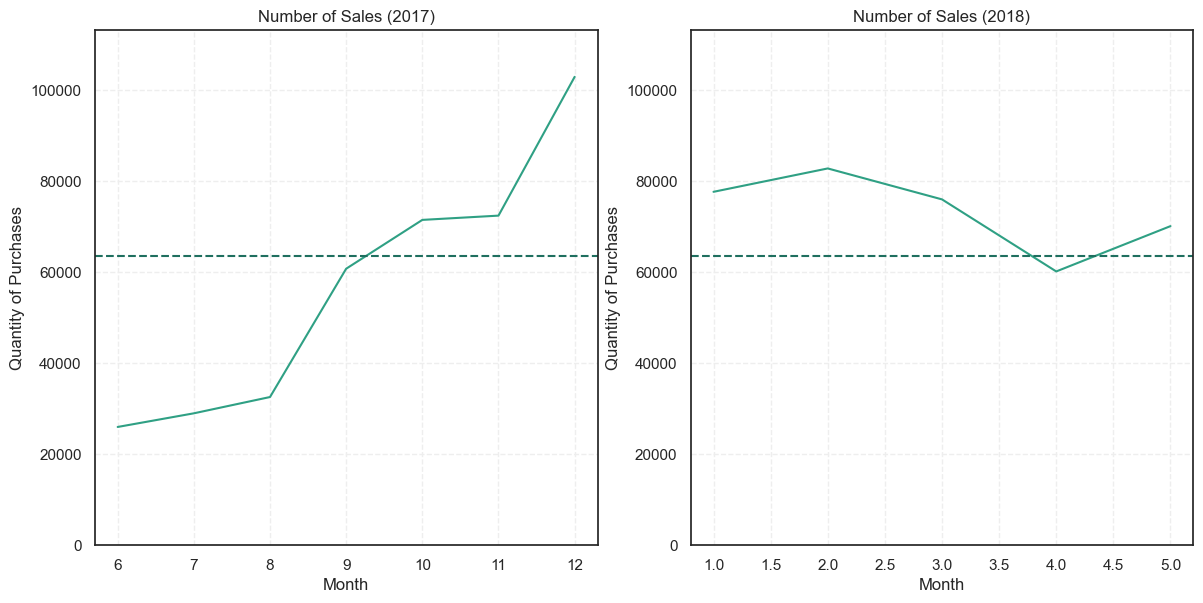

In [51]:
#Projetando os gráficos de quantidade de vendas por mês para os dois anos

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Primeiro gráfico (2017)
ax1.plot(n_orders_2017['session_month'], n_orders_2017['Buy Ts'], color='#2FA084')
ax1.axhline(mean_sales, color='#1F6F5F', linestyle='--', label=f'Mean Sales: {mean_sales}')
ax1.set(xlabel='Month', ylabel='Quantity of Purchases', title='Number of Sales (2017)')
ax1.grid(color='#EEEEEE', linestyle='--', linewidth=1)
ax1.set_ylim(0, n_orders_2017['Buy Ts'].max() * 1.1)

# Segundo gráfico (2018)
ax2.plot(n_orders_2018['session_month'], n_orders_2018['Buy Ts'], color='#2FA084')
ax2.axhline(mean_sales, color='#1F6F5F', linestyle='--', label=f'Mean Sales: {mean_sales}')
ax2.set(xlabel='Month', ylabel='Quantity of Purchases', title='Number of Sales (2018)')
ax2.grid(color='#EEEEEE', linestyle='--', linewidth=1)
ax2.set_ylim(0, n_orders_2017['Buy Ts'].max() * 1.1)

plt.tight_layout(pad=0.5)
plt.show()

In [52]:
costs_logs.head()

,source_id,dt,costs,month
0,1,2017-06-01,75.20,6
1,1,2017-06-02,62.25,6
2,1,2017-06-03,36.53,6
3,1,2017-06-04,55.00,6
4,1,2017-06-05,57.08,6


In [53]:
costs_month = costs_logs.groupby('month').agg({'costs': 'sum'}).reset_index()
costs_month.head()

,month,costs
0,1,33518.52
1,2,32723.03
2,3,30415.27
3,4,22289.38
4,5,22224.27


In [54]:
mean_costs = costs_month['costs'].mean().round(2)

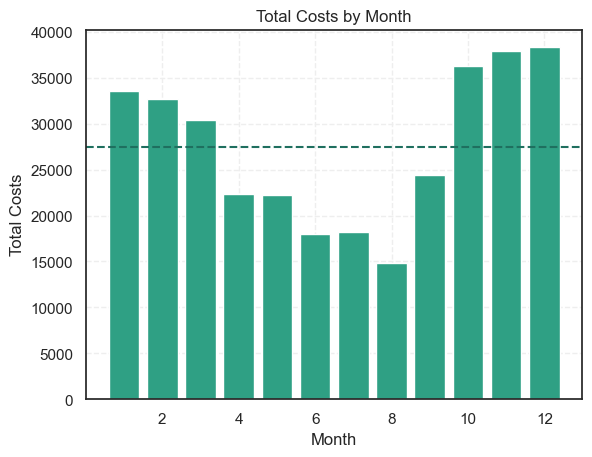

In [55]:


fig, ax = plt.subplots()

ax.bar(costs_month['month'], costs_month['costs'], color='#2FA084')
plt.axhline(mean_costs, color='#1F6F5F', linestyle='--', label=f'Mean Costs: {mean_costs}')
ax.set_xlabel('Month')
ax.set_ylabel('Total Costs')
ax.set_title('Total Costs by Month')
ax.grid(color='#EEEEEE', linestyle='--', linewidth=1)

plt.show()


In [56]:
#Pelas minhas conclusões, os mêses que mais vendem são Dezembro e Fevereiro, muito provavelmente por causa dos férias de Natal e Dia de São Valentim respectivamente.
#O Retorno de Investimento desses dois meses foi mais de 2x do seu custo.
#Os meses de Outubro e Novembro tiveram um alto investimento em marketing mas não tiveram um resultado tão alto quanto os meses previamentes ditos.

#Notas para fazer: fazer o Retorno de Investimento para cada mês e verificar quanto ele rendeu em comparação às vendas

In [57]:
n_orders.head()

,session_month,session_year,Buy Ts
0,6,2017,25988
1,7,2017,28986
2,8,2017,32564
3,9,2017,60757
4,10,2017,71483


In [58]:
costs_month.head()

,month,costs
0,1,33518.52
1,2,32723.03
2,3,30415.27
3,4,22289.38
4,5,22224.27


In [59]:
roc = n_orders.merge(costs_month, left_on='session_month', right_on='month')
roc.head()

,session_month,session_year,Buy Ts,month,costs
0,6,2017,25988,6,18015.00
1,7,2017,28986,7,18240.59
2,8,2017,32564,8,14790.54
3,9,2017,60757,9,24368.91
4,10,2017,71483,10,36322.88


In [60]:
roc = roc.drop(columns='session_month')
roc.head()

,session_year,Buy Ts,month,costs
0,2017,25988,6,18015.00
1,2017,28986,7,18240.59
2,2017,32564,8,14790.54
3,2017,60757,9,24368.91
4,2017,71483,10,36322.88


In [61]:
roc['costs/revenue'] = ((roc['Buy Ts'] / roc['costs']) * 100).round(2)
roc.head()

,session_year,Buy Ts,month,costs,costs/revenue
0,2017,25988,6,18015.00,144.26
1,2017,28986,7,18240.59,158.91
2,2017,32564,8,14790.54,220.17
3,2017,60757,9,24368.91,249.32
4,2017,71483,10,36322.88,196.80


In [62]:
mean_roc = roc['costs/revenue'].mean().round(2)

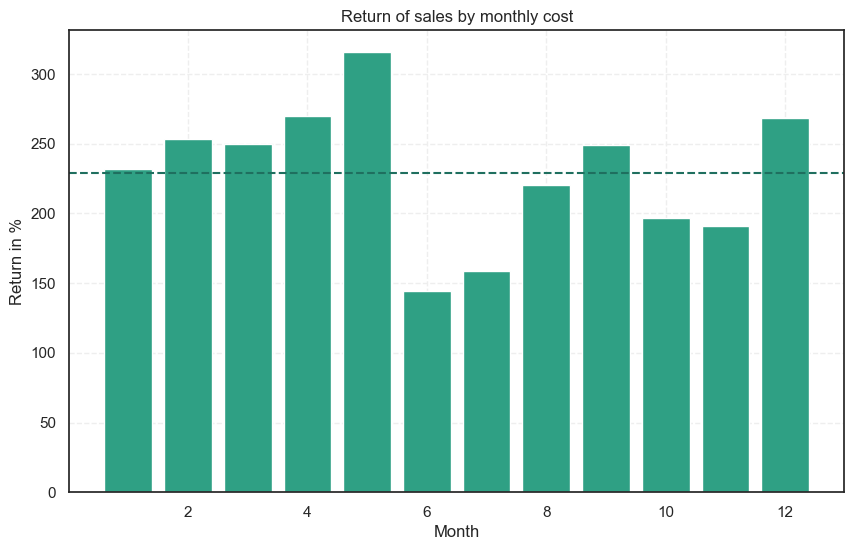

In [63]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(roc['month'], roc['costs/revenue'], color='#2FA084')
plt.axhline(mean_roc, color='#1F6F5F', linestyle='--', label=f'Mean ROMI: {mean_roc}%')
ax.set_xlabel('Month')
ax.set_ylabel('Return in %')
ax.set_title('Return of sales by monthly cost')
ax.grid(color='#EEEEEE', linestyle='--', linewidth=1)

plt.show()

In [64]:
orders_logs.info()

<class 'pandas.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[us]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[us](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [65]:
first_orders = orders_logs.groupby('Uid').agg({'Buy Ts': 'min'}).reset_index().rename(columns={'Buy Ts': 'first_purchase'})
first_orders['first_purchase_month'] = first_orders['first_purchase'].dt.to_period('M')

In [66]:
user_source = visits_logs[['Uid', 'Source Id']].drop_duplicates()

In [67]:
first_orders = pd.merge(first_orders, user_source, on='Uid')

In [68]:
orders_logs['month'] = orders_logs['Buy Ts'].dt.to_period('M')

In [69]:
revenue_df = orders_logs.groupby(['Uid', 'month']).agg({'Revenue': 'sum'}).reset_index()
buyers = first_orders.merge(revenue_df, on='Uid')

In [70]:
revenue_grouped = buyers.groupby(['Source Id', 'month']).agg({'Revenue': 'sum'}).reset_index()

In [71]:
costs_grouped = costs_logs.groupby(['source_id', 'month']).agg({'costs': 'sum'})

In [72]:
report = pd.merge(
    costs_grouped,
    revenue_grouped,
    left_on='source_id',
    right_on='Source Id'
)

In [73]:
report.head()

,costs,Source Id,month,Revenue
0,2186.18,1,2017-06,2563.84
1,2186.18,1,2017-07,3947.25
2,2186.18,1,2017-08,3325.64
3,2186.18,1,2017-09,8193.42
4,2186.18,1,2017-10,11466.14


In [74]:
cohort['ltv'] = report['Revenue'] / report['Source Id']
cohort.head()

,first_month,lifetime_months,Uid,users,retention,ltv
0,2017-06,0,13259,13259,100.00,2563.84
1,2017-06,1,1043,13259,7.87,3947.25
2,2017-06,2,713,13259,5.38,3325.64
3,2017-06,3,814,13259,6.14,8193.42
4,2017-06,4,909,13259,6.86,11466.14


In [75]:
visits = pd.read_csv('../data/visits_log_us.csv')
orders = pd.read_csv('../data/orders_log_us.csv')
costs = pd.read_csv('../data/costs_us.csv')

In [76]:
orders = orders.rename(columns={
    'Buy Ts': 'buy_ts',
    'Revenue': 'revenue',
    'Uid': 'uid'
})

In [77]:
orders['order_month'] =pd.to_datetime(orders['buy_ts'])
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])
costs['dt'] = pd.to_datetime(costs['dt'])

In [78]:
orders.head()

,buy_ts,revenue,uid,order_month
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01 00:10:00
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01 00:25:00
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01 00:27:00
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01 00:29:00
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01 07:58:00


In [79]:
orders['order_month'] = orders['buy_ts'].dt.to_period('M')
orders['first_order_month'] = orders.groupby('uid')['order_month'].transform('min')

In [80]:
costs['costs_month'] = costs['dt'].dt.to_period('M')

In [81]:
cac_mes = pd.merge(
    costs.groupby('costs_month').agg({'costs': 'sum'}),
    orders.groupby('first_order_month').agg({'uid': 'nunique'}),
    left_index=True,
    right_index=True
).reset_index()

In [82]:
cac_mes['cac'] = (cac_mes['costs'] / cac_mes['uid']).round(2)
cac_mes.head()

,costs_month,costs,uid,cac
0,2017-06,18015.00,2023,8.91
1,2017-07,18240.59,1923,9.49
2,2017-08,14790.54,1370,10.80
3,2017-09,24368.91,2581,9.44
4,2017-10,36322.88,4340,8.37


In [83]:
mean_cac = cac_mes['cac'].mean().round(2)

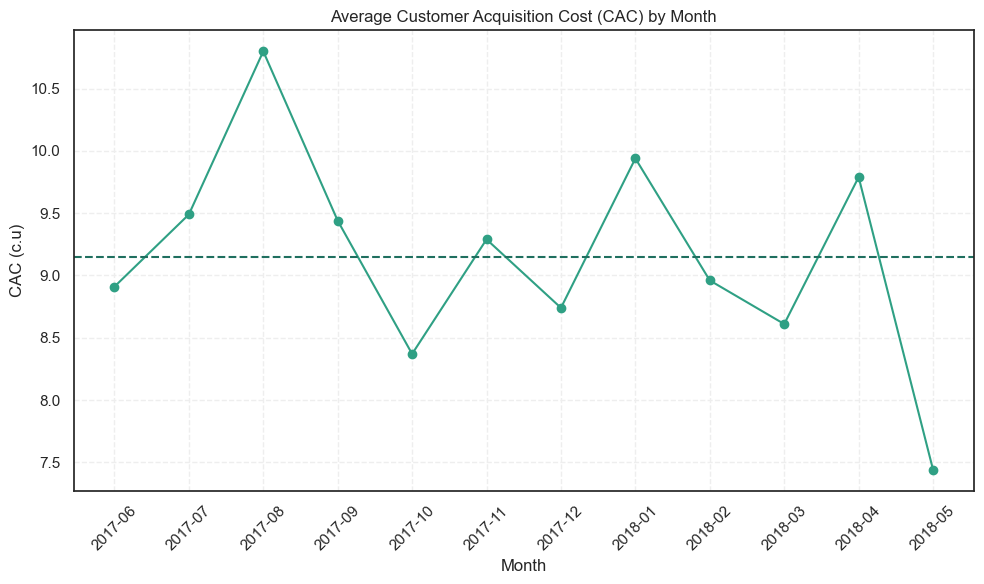

In [84]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(cac_mes['costs_month'].astype(str), cac_mes['cac'], marker='o', color='#2FA084')
ax.axhline(cac_mes['cac'].mean(), color='#1F6F5F', linestyle='--', label=f'Mean CAC: {cac_mes["cac"].mean()}')
ax.set_xlabel('Month')
ax.set_ylabel('CAC (c.u)')
ax.set_title('Average Customer Acquisition Cost (CAC) by Month')
ax.grid(color='#EEEEEE', linestyle='--', linewidth=1)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [85]:
cohorts = orders.groupby(['first_order_month', 'order_month']).agg(revenue=('revenue', 'sum'), n_buyers=('uid', 'nunique')).reset_index()

In [86]:
cohorts.info()

<class 'pandas.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype    
---  ------             --------------  -----    
 0   first_order_month  79 non-null     period[M]
 1   order_month        79 non-null     period[M]
 2   revenue            79 non-null     float64  
 3   n_buyers           79 non-null     int64    
dtypes: float64(1), int64(1), period[M](2)
memory usage: 2.6 KB


In [87]:
cohorts['cohort_lifetime'] = (cohorts['order_month'] - cohorts['first_order_month']).apply(lambda x: x.n)
cohorts.head()

,first_order_month,order_month,revenue,n_buyers,cohort_lifetime
0,2017-06,2017-06,9557.49,2023,0
1,2017-06,2017-07,981.82,61,1
2,2017-06,2017-08,885.34,50,2
3,2017-06,2017-09,1931.30,54,3
4,2017-06,2017-10,2068.58,88,4


In [88]:
cohorts = cohorts.sort_values(['first_order_month', 'cohort_lifetime'])

In [89]:
cost_month = costs.groupby('costs_month').agg(cost=('costs', 'sum')).reset_index()

In [90]:
cohorts = pd.merge(cohorts, cost_month, left_on='order_month', right_on='costs_month')

In [104]:
cohorts['cac'] = (cohorts['cost'] / cohorts['n_buyers']).round(1)
cohorts['ltv'] = (cohorts['revenue'] / cohorts['n_buyers']).round(1)
cohorts['romi'] = (cohorts['ltv'] / cohorts['cac']).round(1)
cohorts.head()

,first_order_month,order_month,revenue,n_buyers,cohort_lifetime,costs_month,cost,cac,ltv,romi,ltv_cumsum
0,2017-06,2017-06,9557.49,2023,0,2017-06,18015.00,8.9,4.7,0.5,4.72
1,2017-06,2017-07,981.82,61,1,2017-07,18240.59,299.0,16.1,0.1,20.82
2,2017-06,2017-08,885.34,50,2,2017-08,14790.54,295.8,17.7,0.1,38.53
3,2017-06,2017-09,1931.30,54,3,2017-09,24368.91,451.3,35.8,0.1,74.29
4,2017-06,2017-10,2068.58,88,4,2017-10,36322.88,412.8,23.5,0.1,97.80


In [92]:
romi_pivot = cohorts.pivot_table(
    index='first_order_month',
    columns='cohort_lifetime',
    values='romi',
    aggfunc='mean'
)

In [93]:
print(romi_pivot)

cohort_lifetime          0         1         2         3         4         5   \
first_order_month                                                               
2017-06            0.530530  0.053826  0.059859  0.079253  0.056950  0.039251   
2017-07            0.633623  0.043583  0.049204  0.019005  0.008968  0.007832   
2017-08            0.488747  0.026535  0.017293  0.014141  0.017665  0.011589   
2017-09            0.597833  0.079412  0.035468  0.267817  0.030844  0.051037   
2017-10            0.597866  0.061338  0.021679  0.020347  0.020101  0.017175   
2017-11            0.554931  0.042523  0.024297  0.040526  0.019860  0.009865   
2017-12            0.542015  0.034047  0.123910  0.153512  0.061535  0.066669   
2018-01            0.416173  0.030383  0.033744  0.021606  0.009516       NaN   
2018-02            0.463807  0.033404  0.012861  0.012180       NaN       NaN   
2018-03            0.562069  0.047693  0.050165       NaN       NaN       NaN   
2018-04            0.475594 

In [94]:
cumsum_romi = romi_pivot.cumsum(axis=1).round(2)

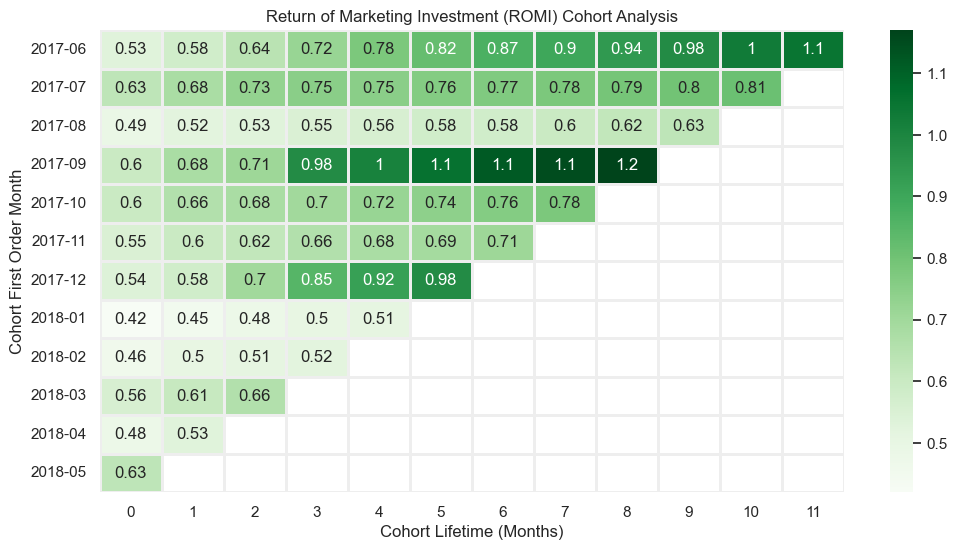

In [95]:
sns.set_theme(style='white')
plt.figure(figsize=(12,6))
plt.title('Return of Marketing Investment (ROMI) Cohort Analysis')
sns.heatmap(cumsum_romi, annot=True, linewidths=1, linecolor='#EEEEEE', cmap='Greens')
plt.xlabel('Cohort Lifetime (Months)')
plt.ylabel('Cohort First Order Month')

plt.show()

In [96]:
#Minha interpretação desse heatmap é: Os maiores valores de ROMI estão concentrado por volta de dezembro até maio,
#mas essa tendência é maior quando o usuário tem um histórico de compra. Na minha opinião, os investimentos devem ser feitos
#no 2° semestre do ano para que no final pra início do ano seguinte, as vendas estejam garantidas

<b>Resposta do aluno
    </b> 
<a class="tocSkip">Sinceramente, não entendi quase nada, estou tendo muita dificuldade pra entender como fazer o coortes</a>
</div>

<div class="alert alert-block alert-danger">
<b> Comentário v2: </b> <a class="tocSkip"></a>


O código ainda necessita de ajustes. Vou passar um passo a passo mais detalhado de como resolver: 

```python

## Código gerado pela revisora - Repare nos agrupamentos utilizando groupby 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ler os dados (já no seu caso)
visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs = pd.read_csv('/datasets/costs_us.csv')

# Renomeando as colunas em 'orders'
orders = orders.rename(columns={
    'Buy Ts': 'buy_ts',        # Renomeia 'Buy Ts' para 'buy_ts'
    'Revenue': 'revenue',      # Renomeia 'Revenue' para 'revenue'
    'Uid': 'uid'               # Renomeia 'Uid' para 'uid'
})


# 2. Converter as colunas relevantes para o formato datetime
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])
costs['dt'] = pd.to_datetime(costs['dt'])

# 3. Criar as colunas 'order_month' e 'first_order_month' em orders
orders['order_month'] = orders['buy_ts'].dt.to_period('M')
orders['first_order_month'] = orders.groupby('uid')['order_month'].transform('min')

# 4. Agrupar os dados de custos e pedidos por mês
costs['costs_month'] = costs['dt'].dt.to_period('M')

# 5. Calcular o CAC por mês fazendo o merge entre custos e pedidos
CAC_por_mes = pd.merge(
    costs.groupby('costs_month').agg({'costs': 'sum'}),
    orders.groupby('first_order_month').agg({'uid': 'nunique'}),  # Número de usuários únicos
    left_index=True,
    right_index=True
)

# 6. Calcular o Custo de Aquisição (CAC)
CAC_por_mes['cac'] = CAC_por_mes['costs'] / CAC_por_mes['uid']

# 7. Plotar o CAC ao longo do tempo
CAC_por_mes['cac'].plot(figsize=(14,7), title='CAC Médio por mês', xlabel='Mês', ylabel='CAC (c.u.)')
plt.show()

# 8. Criar coortes com base no primeiro mês de pedido e calcular receita e número de compradores
cohorts = orders.groupby(['first_order_month', 'order_month']).agg(
    revenue=('revenue', 'sum'),
    n_buyers=('uid', 'nunique')  # Compradores únicos
).reset_index()

# 9. Calcular a duração da coorte em meses
cohorts['cohort_lifetime'] = (
    (cohorts['order_month'].dt.year - cohorts['first_order_month'].dt.year) * 12 +
    (cohorts['order_month'].dt.month - cohorts['first_order_month'].dt.month)
)

# 10. Ordenar as coortes por 'first_order_month' e 'cohort_lifetime'
cohorts = cohorts.sort_values(['first_order_month', 'cohort_lifetime'])

# 11. Agrupar os dados de custos por mês e fazer o merge com as coortes
cost_per_month = costs.groupby('costs_month').agg(costs=('costs', 'sum')).reset_index()

# Fazer o merge dos dados de custo com as coortes com base no 'order_month'
cohorts = pd.merge(cohorts, cost_per_month, left_on='order_month', right_on='costs_month')

# 12. Calcular CAC, LTV e ROMI
cohorts['cac'] = cohorts['costs'] / cohorts['n_buyers']
cohorts['ltv'] = cohorts['revenue'] / cohorts['n_buyers']
cohorts['romi'] = cohorts['ltv'] / cohorts['cac']

# 13. Criar uma tabela dinâmica para o ROMI ao longo da duração da coorte
romi_pivot = cohorts.pivot_table(index='first_order_month', columns='cohort_lifetime', values='romi', aggfunc='mean')

# 14. Calcular a soma cumulativa de ROMI para cada coorte
cum_sum_romi = romi_pivot.cumsum(axis=1).round(2)

# 15. Plotar o heatmap de ROMI
sns.set(style='white')
plt.figure(figsize=(13, 9))
plt.title('Cohort de ROMI')
sns.heatmap(cum_sum_romi, annot=True, linewidths=1, linecolor='gray', cmap='coolwarm')
plt.show()

# (opcional) readicionando código anterior para manter códigos posteriores funcionais
orders['order_month'] = orders['buy_ts'].dt.to_period('M')
orders['first_order_month'] = orders.groupby('uid')['order_month'].transform('min')
# 8. Criar coortes com base no primeiro mês de pedido e calcular receita e número de compradores
cohorts = orders.groupby(['first_order_month', 'order_month']).agg(
    revenue=('revenue', 'sum'),
    n_buyers=('uid', 'nunique')  # Compradores únicos
).reset_index()

margin_rate = 0.4

cohorts['gp'] = cohorts['revenue'] * margin_rate
cohorts['age'] = (cohorts['order_month'] - cohorts['first_order_month'])#.apply(attrgetter('n'))
cohorts['ltv'] = cohorts['gp'] / cohorts['n_buyers']


```

<div class="alert alert-block alert-danger">
<b> Comentário: </b> <a class="tocSkip"></a>

Aqui precisamos calcular o `ROI` / `ROMI` também por cohort, pois os grupos podem ter valores diferentes de `LTV` e isso pode influenciar no resultado final. O cálculo da métrica pode ser feito como algo assim:
    
```python
your_agg_df['romi'] = your_agg_df['ltv'] / your_agg_df['cac']
```

O resultado pode ser apresentado como uma `pivot_table` por `cohort`, conforme você fez para outros indicadores em seu projeto. Adicionalmente, você pode analisar o `ROMI` por origem.
    
```markdown
|                   |      |    |    |   |   |   |   |   |   |   |    |    |
|-------------------|------|----|----|---|---|---|---|---|---|---|----|----|
| cohort            | 0    | 1  | 2  | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 |
| first_order_month |      |    |    |   |   |   |   |   |   |   |    |    |
| 2017-06           | 0.53 | .. | .. |   |   |   |   |   |   |   |    |    |
| 2017-07           | 0.63 | .. |    |   |   |   |   |   |   |   |    |    |
| 2017-08           | 0.49 | .. |    |   |   |   |   |   |   |   |    |    |
| 2017-09           | 0.60 |    |    |   |   |   |   |   |   |   |    |    |
| 2017-10           | 0.60 |    |    |   |   |   |   |   |   |   |    |    |
| 2017-11           | 0.55 |    |    |   |   |   |   |   |   |   |    |    |
| 2017-12           | 0.54 |    |    |   |   |   |   |   |   |   |    |    |
| 2018-01           | 0.42 |    |    |   |   |   |   |   |   |   |    |    |
| 2018-02           | 0.46 |    |    |   |   |   |   |   |   |   |    |    |
| 2018-03           | 0.56 |    |    |   |   |   |   |   |   |   |    |    |
| 2018-04           | 0.48 |    |    |   |   |   |   |   |   |   |    |    |
| 2018-05           | 0.63 |    |    |   |   |   |   |   |   |   |    |    |
 ```
    
Exemplo de código:    
```python
cohorts = orders_log.groupby(['first_order_month', 'order_month']).agg(revenue=('revenue','sum'), n_buyers=('user_id', 'nunique')).reset_index()

# calcular a vida útil do coorte
cohorts['cohort_lifetime'] = (cohorts['order_month'] - cohorts['first_order_month']).apply(lambda x: x.n)

# ordenar o dataframe por 'first_order_month' e 'cohort_lifetime'
cohorts = cohorts.sort_values(['first_order_month', 'cohort_lifetime'])

# mesclar com os dados de custos
costs['costs_month'] = pd.to_datetime(costs['ad_date']).dt.to_period('M')
cost_per_month = costs.groupby('costs_month').agg(costs=('costs', 'sum')).reset_index()

cohorts = pd.merge(cohorts, cost_per_month, left_on='order_month', right_on='costs_month')

# calcular cac, ltv e romi
cohorts['cac'] = cohorts['costs'] / cohorts['n_buyers']
cohorts['ltv'] = cohorts['revenue'] / cohorts['n_buyers']
cohorts['romi'] = cohorts['ltv'] / cohorts['cac']

# criar a tabela dinâmica com 'cohort_lifetime' como colunas
romi_pivot = cohorts.pivot_table(index='first_order_month', columns='cohort_lifetime', values='romi', aggfunc='mean').round(2)

# calcular a soma acumulada usando o comando cumsum
...continue o código
```

</div>

In [97]:
#Com o gráfico de retorno das receitas por custo mensal do dinheiro investido em marketing, podemos ver quais meses fizeram o dinheiro valer mais
#Os meses que mais tiveram vendas foram de fevereiro e o de dezembro, por causa dos seus feriados. Com esse novo gráfico podemos ver que os meses de abril e de maio
#tiveram um algo retorno de investimento. Com esses insights, eu apontaria o destino dos investimentos nesses meses [fevereiro, abril, maio e dezembro].

In [98]:
cohorts.head()

,first_order_month,order_month,revenue,n_buyers,cohort_lifetime,costs_month,cost,cac,ltv,romi
0,2017-06,2017-06,9557.49,2023,0,2017-06,18015.00,8.905091,4.724414,0.530530
1,2017-06,2017-07,981.82,61,1,2017-07,18240.59,299.026066,16.095410,0.053826
2,2017-06,2017-08,885.34,50,2,2017-08,14790.54,295.810800,17.706800,0.059859
3,2017-06,2017-09,1931.30,54,3,2017-09,24368.91,451.276111,35.764815,0.079253
4,2017-06,2017-10,2068.58,88,4,2017-10,36322.88,412.760000,23.506591,0.056950


In [99]:
cohorts['ltv_cumsum'] = cohorts.groupby('first_order_month')['ltv'].cumsum().round(2)
ltv_cumsum = cohorts.pivot_table(
    values='ltv_cumsum',
    index='first_order_month',
    columns='cohort_lifetime',
    fill_value=0
)
print(ltv_cumsum)

cohort_lifetime      0      1      2       3       4       5       6       7   \
first_order_month                                                               
2017-06            4.72  20.82  38.53   74.29   97.80  120.01  151.02  176.05   
2017-07            6.01  18.41  39.44   50.23   57.17   65.06   71.48   78.48   
2017-08            5.28  16.43  28.28   40.46   57.38   69.52   79.14   91.75   
2017-09            5.64  27.83  41.28  179.95  199.83  225.92  253.36  270.32   
2017-10            5.00  16.29  23.04   30.46   37.53   44.79   51.36   58.84   
2017-11            5.15  12.49  19.28   31.79   39.25   43.83   51.39    0.00   
2017-12            4.74  12.55  51.92  100.06  127.49  151.01    0.00    0.00   
2018-01            4.14  12.86  25.22   36.42   41.12    0.00    0.00    0.00   
2018-02            4.16  12.77  17.71   24.65    0.00    0.00    0.00    0.00   
2018-03            4.84  16.65  35.87    0.00    0.00    0.00    0.00    0.00   
2018-04            4.66  22.

In [100]:
ltv_pivot = cohorts.pivot_table(
    index='first_order_month',
    columns='cohort_lifetime',
    values='ltv',
    aggfunc='mean'
)
ltv_cumsum = ltv_pivot.cumsum(axis=1).round(2)

In [101]:
ltv_cumsum.head()

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11
first_order_month,,,,,,,,,,,,
2017-06,4.72,20.82,38.53,74.29,97.80,120.01,151.02,176.05,195.35,222.58,248.26,258.07
2017-07,6.01,18.41,39.44,50.23,57.17,65.06,71.48,78.48,85.86,98.72,110.24,NaN
2017-08,5.28,16.43,28.28,40.46,57.38,69.52,79.14,91.75,112.82,121.13,NaN,NaN
2017-09,5.64,27.83,41.28,179.95,199.83,225.92,253.36,270.32,281.37,NaN,NaN,NaN
2017-10,5.00,16.29,23.04,30.46,37.53,44.79,51.36,58.84,NaN,NaN,NaN,NaN


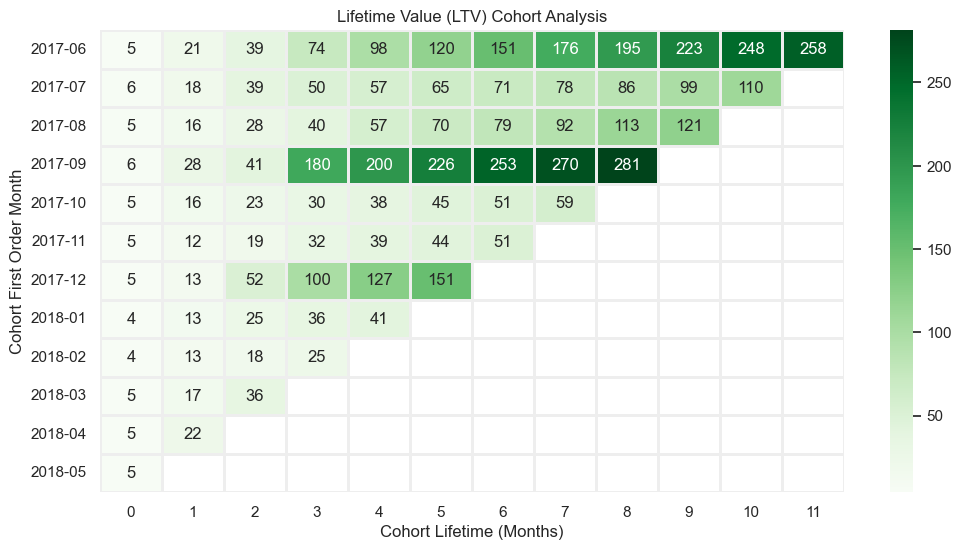

In [102]:
sns.set_theme(style='white')
plt.figure(figsize=(12,6))
plt.title('Lifetime Value (LTV) Cohort Analysis')
sns.heatmap(ltv_cumsum, annot=True, linewidths=1, linecolor='#EEEEEE', cmap='Greens', fmt='.0f')
plt.xlabel('Cohort Lifetime (Months)')
plt.ylabel('Cohort First Order Month')

plt.show()